# Week 5 (Dimension Reduction, SVM)

## Dimension Reduction

### `make_regression`을 이용한 PCA Regression

https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_regression.html

scikit-learn에서는 `make_regression` 함수를 이용하여 회귀분석을 연습하기 위한 데이터셋을 만들 수 있다. 이를 이용해서 Principal Component Regression을 연습하는 과제를 진행해보자.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_regression

### Q1 `make_regression` 함수로 데이터를 생성해보자

독립변수는 X1부터 X10까지, 종속변수는 Y를 생성하자. 표본 크기는 1000으로 설정하고, `noise`, `random_state`, `bias`등의 변수는 자유롭게 설정해보자.

In [ ]:
# make_regression로 데이터 생성

X, Y = make_regression(
    n_samples = 1000,
    n_features = 10, # 독립변수 개수
    noise = 10, # 노이즈 추가
    bias = 10, # 절편 값
    random_state = 10
)

feature_names = [f"X{i}" for i in range (1,11)] # 변수 명 X1 ~ X10으로 지정
df = pd.DataFrame(X, columns = feature_names)
df["Y"] = Y

df.head()

# 데이터 형태 : Y = Xb + bias + e, e~N(0,10^2)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,Y
0,1.509902,-0.384063,-0.558412,1.429614,-1.310223,0.113020,0.099973,-1.921050,1.496690,0.292636,294.072440
1,-1.171324,-0.230646,1.494811,-0.202528,-0.864532,0.881837,-0.010996,-2.752623,-0.511077,-0.127744,-196.424457
2,0.973403,1.908480,1.020938,-2.347173,0.701773,-0.781009,-0.541510,-0.941968,0.150226,-1.403477,-151.688935
3,1.506892,0.771084,0.082295,-1.311550,0.361949,0.933130,-0.082276,0.121898,0.120363,-0.231210,112.886110
4,0.470463,-1.788403,0.343220,0.393399,0.036582,-0.688070,0.833513,0.579788,-1.102778,-0.336433,28.742992


### Q2 EDA를 해보자

각 변수별 히스토그램, scatterplot matrix, correlation matrix, 요약통계량(descriptive statistics)를 그려보자

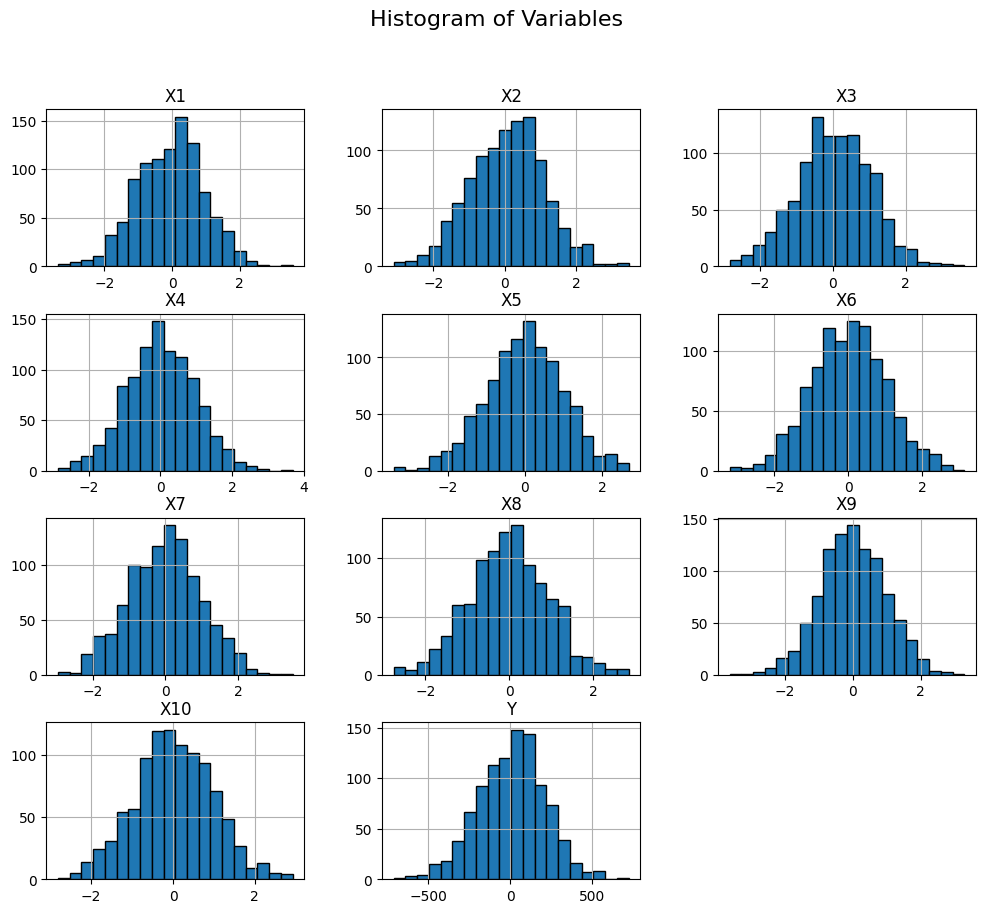

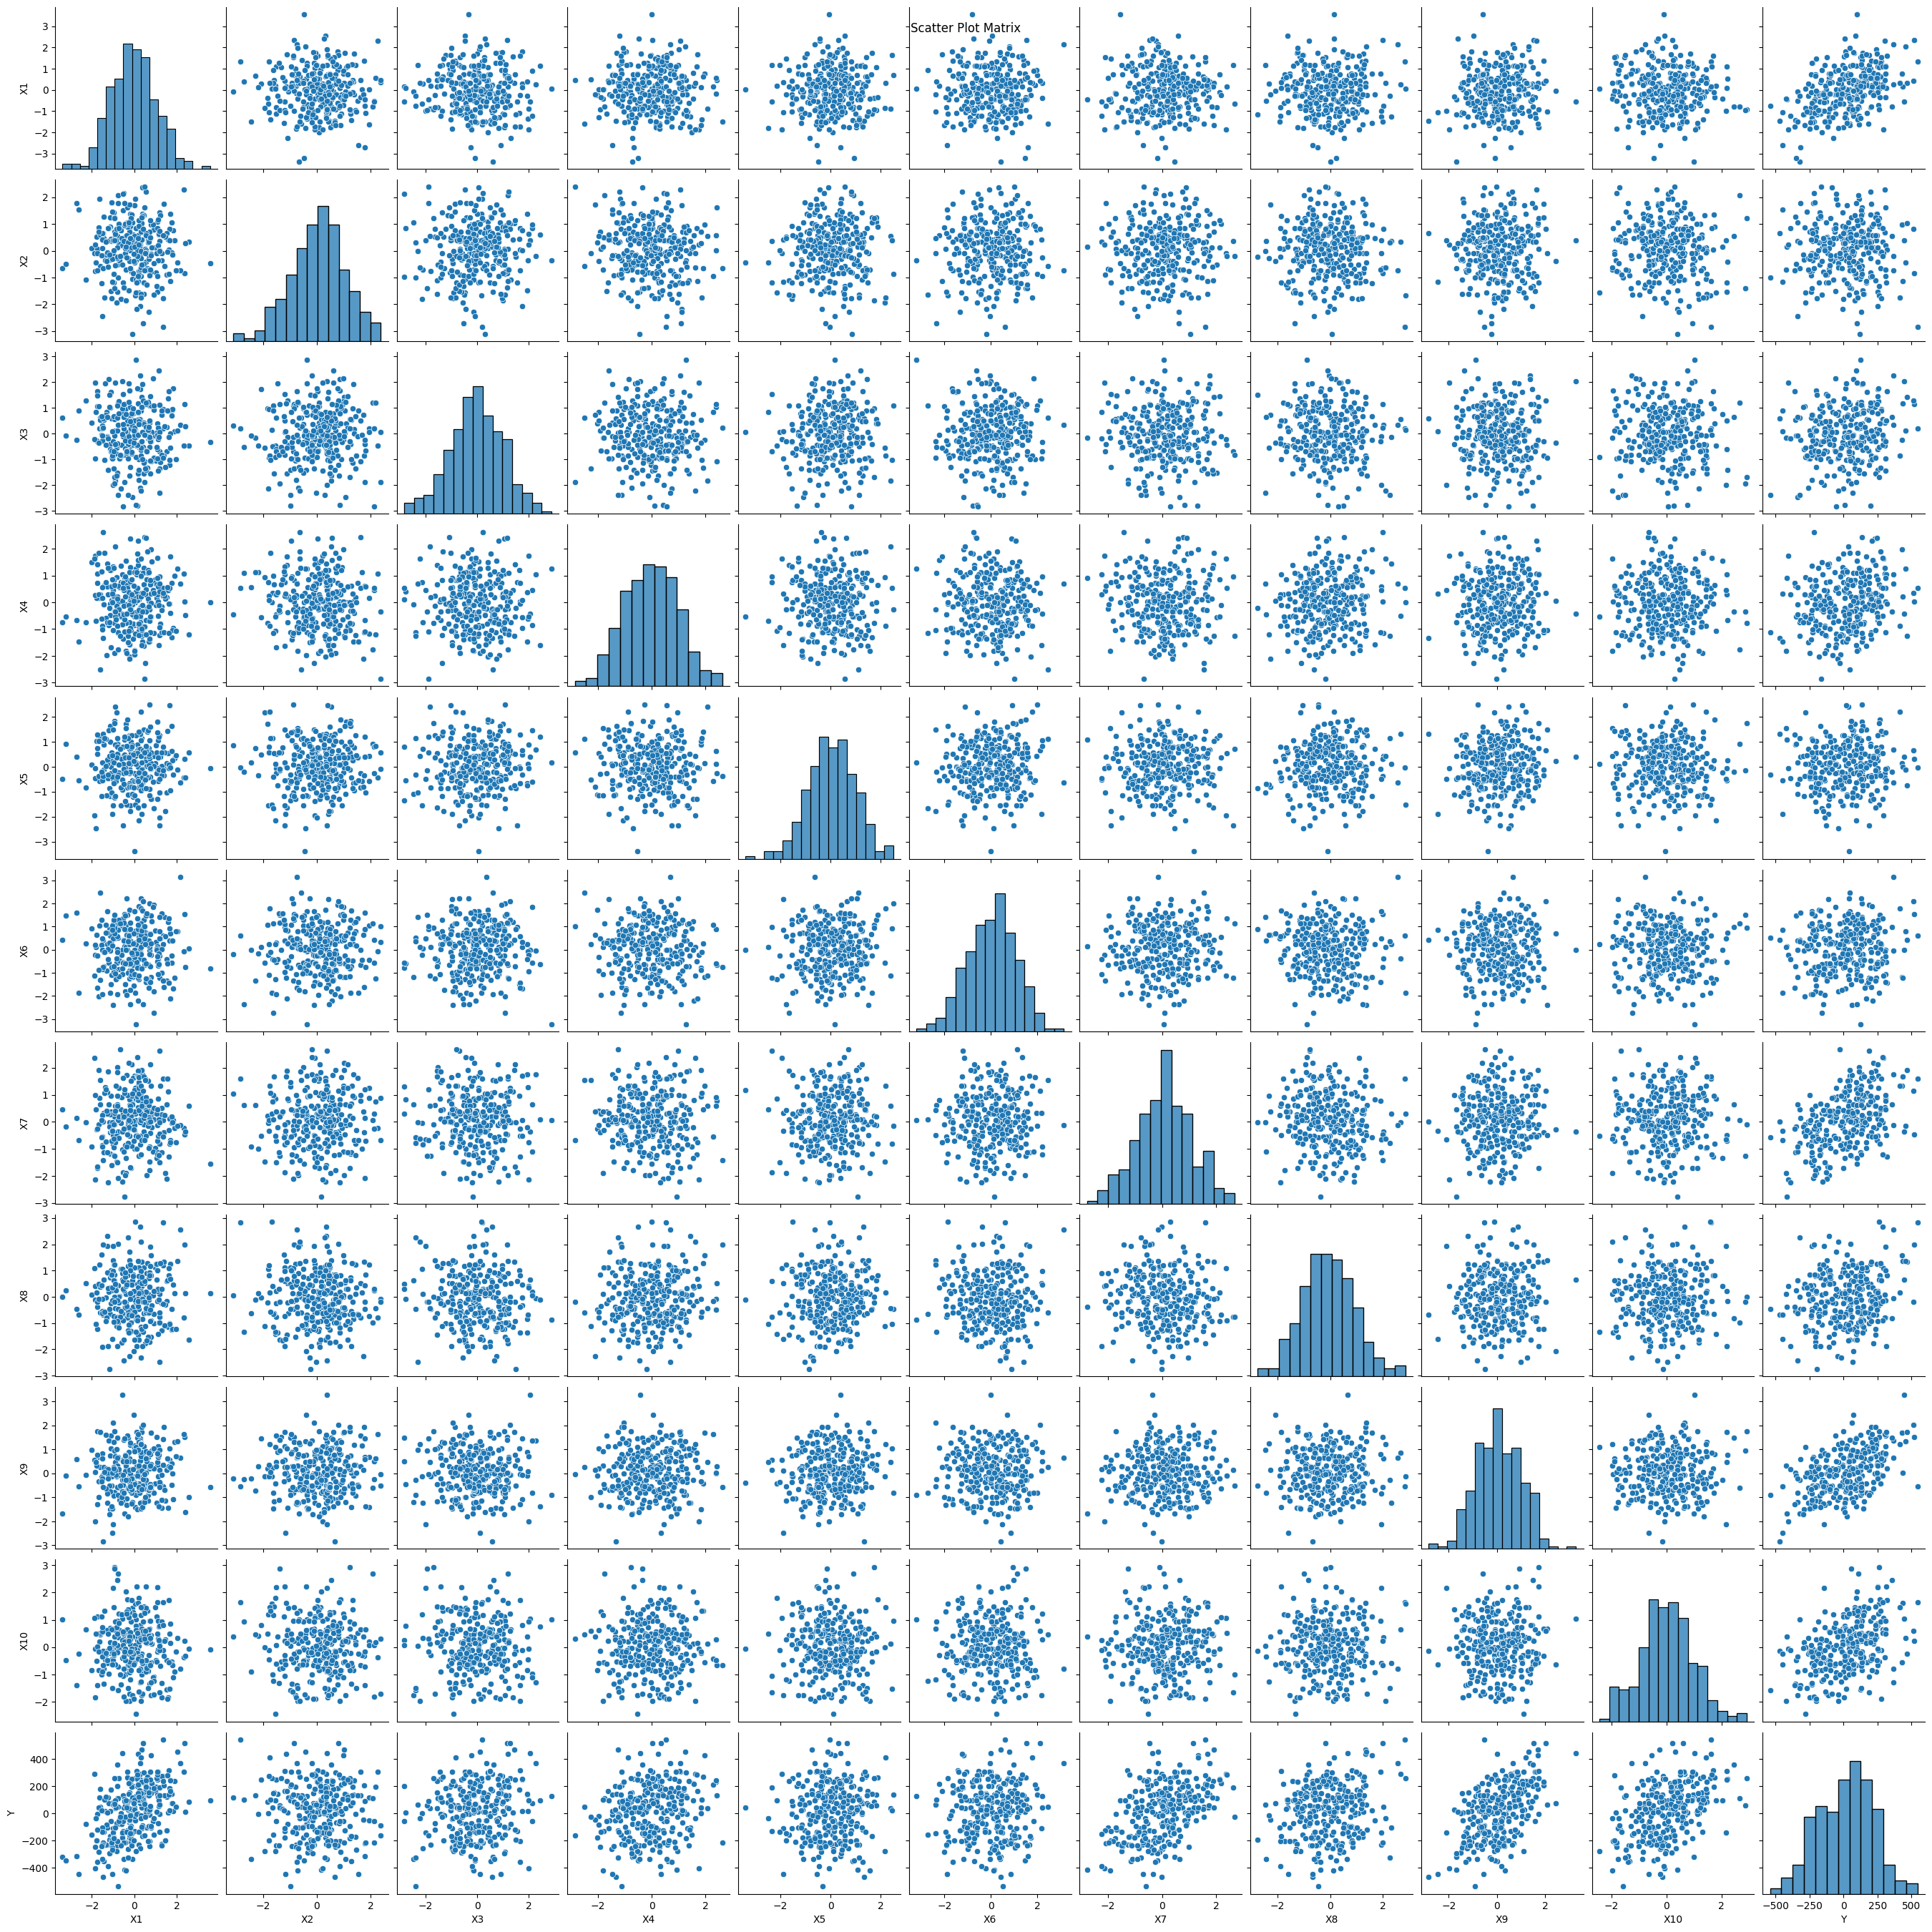

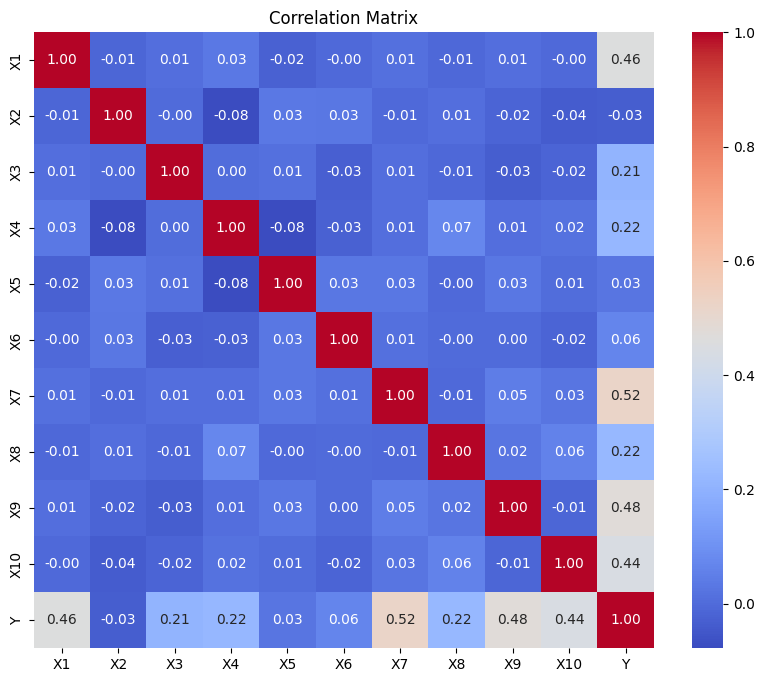

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,Y
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.054771,0.060206,0.027299,0.013447,-0.004580,0.012956,-0.017103,-0.012635,0.005036,0.021165,7.580824
std,0.989457,1.041354,1.009452,0.969202,1.000522,1.008969,0.999550,0.948645,0.969915,0.956622,204.214762
min,-3.372347,-3.112645,-2.831778,-2.862382,-3.393109,-3.214030,-2.952987,-2.753242,-3.621639,-2.815061,-712.414247
25%,-0.761071,-0.659241,-0.613579,-0.643141,-0.643014,-0.666776,-0.714693,-0.633211,-0.630229,-0.590180,-130.113041
50%,-0.008191,0.098886,0.044624,0.001790,0.006427,0.022003,0.007104,-0.008570,-0.024466,0.013317,21.107342
75%,0.570101,0.744831,0.739097,0.676918,0.682364,0.715830,0.633469,0.617184,0.663855,0.676993,143.747448
max,3.561219,3.454845,3.609161,3.691489,2.675077,3.142285,3.503309,2.848074,3.286370,2.925324,724.214827


In [6]:
# 히스토그램
import matplotlib.pyplot as plt
df.hist(bins=20, figsize=(12,10), edgecolor='black')
plt.suptitle("Histogram of Variables", fontsize=16)
plt.show()

# Scatterplot matrix
import seaborn as sns

sns.pairplot(df.sample(300))
plt.suptitle("Scatter Plot Matrix")
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 8))
corr = df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


# 요약 통계량
df.describe()

### Q3 `StandardScaler` 로 scaling을 해보자

X 변수들에 대해 `StandarScaler`를 이용하여 표준화를 해보자.
PCA를 하기 전에 스케일링을 한다는 점을 유의하자.

In [ ]:
from sklearn.preprocessing import StandardScaler

# 스케일링하기
X=df.drop("Y", axis=1)
Y=df["Y"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # 평균 0, 표준편차 1로

X_scaled[:5]

array([[ 1.5821356 , -0.42683999, -0.58051681,  1.46189929, -1.30561584,
         0.0992241 ,  0.11718782, -2.01273336,  1.53869152,  0.28392282],
       [-1.12901431, -0.27944185,  1.45449805, -0.22294994, -0.85993399,
         0.86158824,  0.00611336, -2.88976218, -0.53238846, -0.15573957],
       [ 1.03964904,  1.77576393,  0.98482746, -2.43685279,  0.70633775,
        -0.78730118, -0.52490542, -0.98013253,  0.14976858, -1.48998728],
       [ 1.57909229,  0.68298888,  0.05450826, -1.36778623,  0.36652118,
         0.91245113, -0.06523457,  0.14188762,  0.11896368, -0.26395112],
       [ 0.5310961 , -1.77608636,  0.31311948,  0.39222152,  0.04116095,
        -0.69514166,  0.85142495,  0.62480618, -1.14274746, -0.37400078]])

### Q4 `PCA`를 해보자

`PCA` 함수를 이용하여 PCA를 해보자. 또 다음을 해보자.

- PC1 부터 PC10 까지 Scree plot을 그려보자
- PC1과 PC2를 가지고 scatterplot을 그려보자.

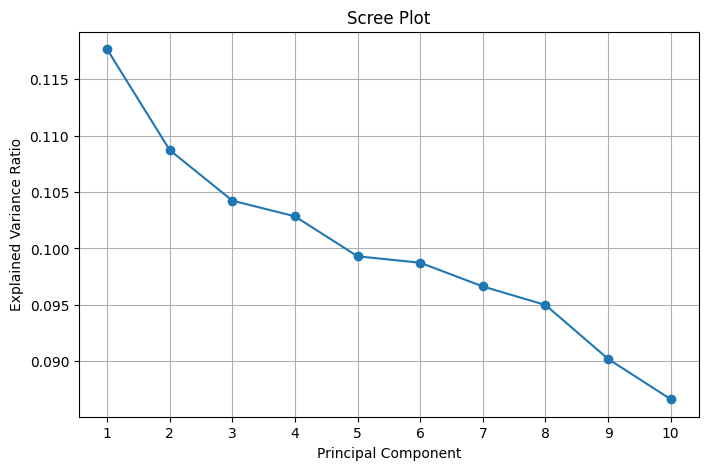

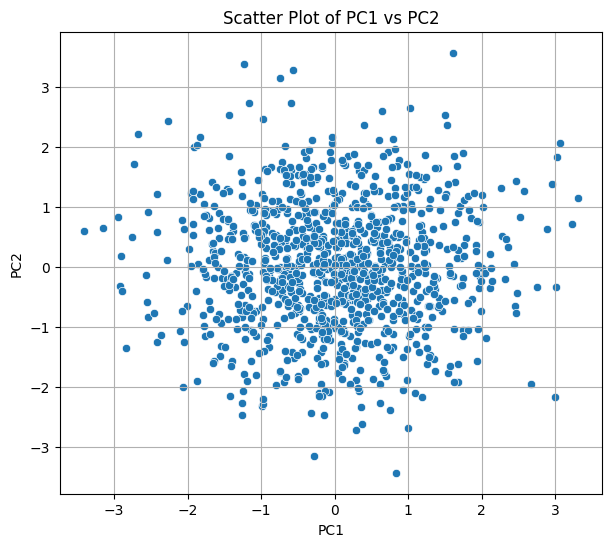

In [8]:
from sklearn.decomposition import PCA

# PCA 계산하기
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Scree plot 그리기 -> 각 주성분이 설명하는 분산 비율 보여줌
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), explained_variance, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(range(1, 11))
plt.grid()
plt.show()

# PC1 와 PC2 산점도 그리기
plt.figure(figsize=(7,6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Scatter Plot of PC1 vs PC2")
plt.grid()
plt.show()



### Q5 `train_test_split`을 해보자

Train set과 Test set을 6:4 비율로 나눠보자

In [9]:
from sklearn.model_selection import train_test_split

# train set과 test set 나누기
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, Y,
    test_size=0.4,      
    random_state=10     
)

###  Q6 Principal Component Regression을 진행해보자.

Q5에서 만든 데이터로부터 다음의 과정으로 문제를 풀어보자.
- Y를 종속변수(`y_train`), `X_train`의 PC1을 종속변수로 하여 Linear Regression을 적합한다.
- `y_pred`과 `y_train`을 비교하여 train error의 MSE를 구한다.
- Principal component을 하나 늘려 Linear regression을 적합한다. 즉 Y에 대해 PC1, PC2으로 Linear Regression을 적합한다.
- 마찬가지로 train error의 MSE를 구한다.
- PC10까지 같은 과정을 반복하고, MSE를 비교한다.



In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# train MSE 저장
mse_train = []

# 회귀모형 적합
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train)

# PC 1개부터 10까지 늘려가며 회귀
for k in range(1,11):
    Xk_train = X_train_pca[:,:k]
    model=LinearRegression()
    model.fit(Xk_train, y_train)
    
    y_pred_train = model.predict(Xk_train)
    mse = mean_squared_error(y_train, y_pred_train)
    mse_train.append(mse)

    print(f"PC 1~{k} 사용 | Train MSE = {mse:.4f}")

print("\nTrain MSE list:")
print(mse_train)

PC 1~1 사용 | Train MSE = 38426.1513
PC 1~2 사용 | Train MSE = 32414.6409
PC 1~3 사용 | Train MSE = 22930.8098
PC 1~4 사용 | Train MSE = 22058.9100
PC 1~5 사용 | Train MSE = 21626.0516
PC 1~6 사용 | Train MSE = 10442.4293
PC 1~7 사용 | Train MSE = 8581.3429
PC 1~8 사용 | Train MSE = 785.9804
PC 1~9 사용 | Train MSE = 93.8158
PC 1~10 사용 | Train MSE = 93.3898

Train MSE list:
[38426.15127340822, 32414.64088449447, 22930.809778134146, 22058.910046995345, 21626.051580227126, 10442.429294248246, 8581.342914569916, 785.9803792382668, 93.81579047888735, 93.3898479185712]


### Q7 Test error을 계산해보자.

위 과정에서 적합한 모형을 바탕으로 `y_test`을 추정하고 `y_test`와의 MSE를 계산하여 test error을 구해보자.

PC 1~1개 | Test MSE = 45463.0849
PC 1~2개 | Test MSE = 39422.0899
PC 1~3개 | Test MSE = 29538.5312
PC 1~4개 | Test MSE = 27999.6136
PC 1~5개 | Test MSE = 28035.1515
PC 1~6개 | Test MSE = 12373.5110
PC 1~7개 | Test MSE = 11151.0594
PC 1~8개 | Test MSE = 923.6668
PC 1~9개 | Test MSE = 96.3393
PC 1~10개 | Test MSE = 96.1623

Test MSE list:
[45463.08489684844, 39422.08991157581, 29538.53121575432, 27999.61360172806, 28035.1515469958, 12373.511030069985, 11151.059368212007, 923.6668226711365, 96.33933304685374, 96.16233641477935]


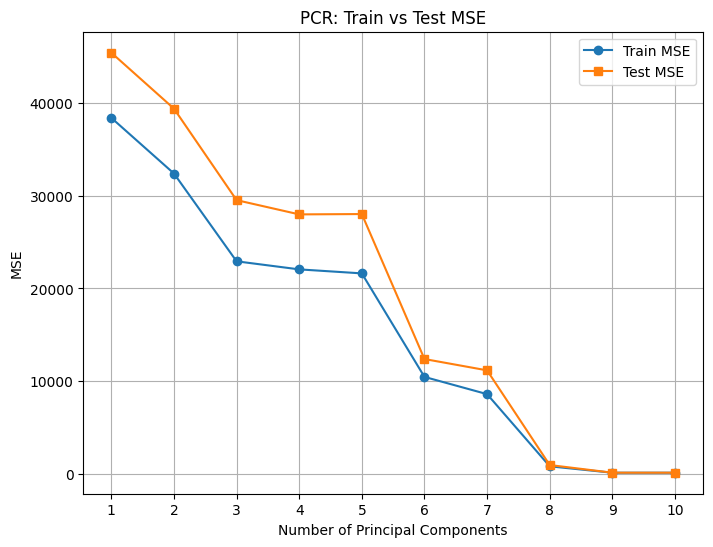

In [ ]:
# test MSE 저장
mse_test = []
X_test_pca = pca.transform(X_test)

for k in range(1, 11):
    Xk_train = X_train_pca[:, :k]
    Xk_test  = X_test_pca[:, :k]

    model = LinearRegression()
    model.fit(Xk_train, y_train)

    y_pred_test = model.predict(Xk_test)
    mse = mean_squared_error(y_test, y_pred_test)
    mse_test.append(mse)

    print(f"PC 1~{k}개 | Test MSE = {mse:.4f}")

print("\nTest MSE list:")
print(mse_test)

plt.figure(figsize=(8,6))

plt.plot(range(1, 11), mse_train, marker='o', label='Train MSE')
plt.plot(range(1, 11), mse_test, marker='s', label='Test MSE')

plt.xlabel('Number of Principal Components')
plt.ylabel('MSE')
plt.title('PCR: Train vs Test MSE')
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True)

plt.show()

# PC1~8 사용이 적절해보임

## SVM

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.svm import SVC, SVR

- SVC (Classification)
- SVR (Regression)

### 1.1 Hard Margin Classifier

#### Q1.1 Hard Margin Classifier란? :

데이터를 완벽하게 분리할 수 있을 때 사용하는 SVM
한 점도 잘못 분류하면 안되며, 마진을 최대화하는데 집중한다. 
-> 이러한 특성으로 실제 데이터에는 오분류를 일부 허용하되 노이즈에 대응 가능한 soft margin classifier을 사용한다. 

In [18]:
# 데이터셋 생성
X = np.array([[1, 2], [2, 3], [3, 3], [6, 6], [7, 8], [8, 8]])
y = np.array([0, 0, 0, 1, 1, 1])

#### Q1.2 위 데이터셋을 2차원의 좌표평면에 시각화해주세요.

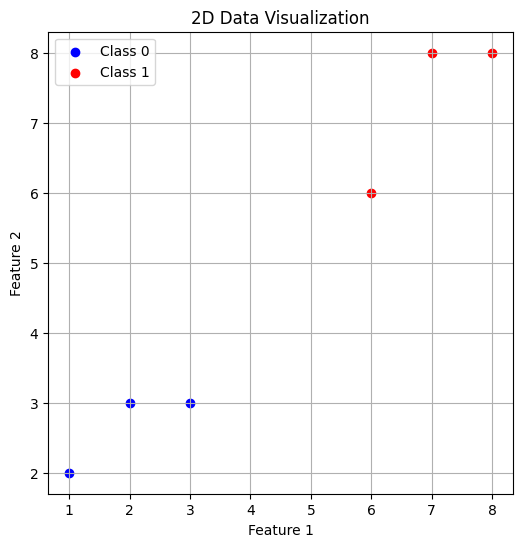

In [19]:
X_class0 = X[y == 0]
X_class1 = X[y == 1]

# 시각화
plt.figure(figsize=(6,6))
plt.scatter(X_class0[:, 0], X_class0[:, 1], color='blue', label='Class 0')
plt.scatter(X_class1[:, 0], X_class1[:, 1], color='red', label='Class 1')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('2D Data Visualization')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
# Hard Margin SVM 모델 학습
model = SVC(kernel='linear', C=1e10)
model.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10000000000.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


#### Q1.3 하단 w와 b는 모델 학습으로 찾아낸 Wx+b의 계수와 상수항입니다. w와 b를 정의해주세요.

[0.33333333 0.33333333]
-3.0


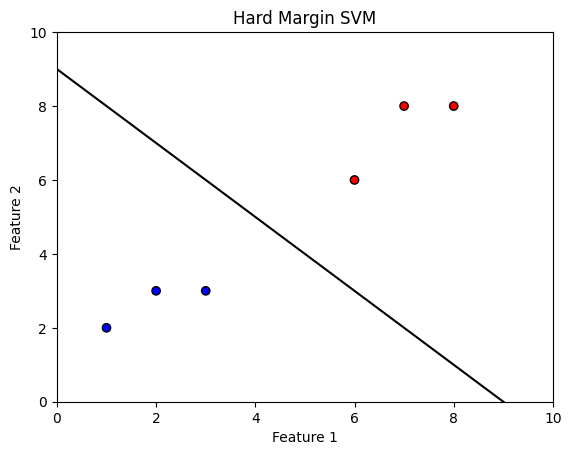

In [ ]:
# 결정 경계 시각화

# SVM 에서 결정경계 : w1x1 + w2x2 + b = 0
w = model.coef_[0]
b = model.intercept_[0]
print(w) # 1/3, 1/3
print(b) # -3.0
x_plot = np.linspace(0, 10, 100)
y_plot = -(w[0] * x_plot + b) / w[1]

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.plot(x_plot, y_plot, 'k-')
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Hard Margin SVM')
plt.show()

### 1.2 Soft Margin Classifier

#### Q2.1 Soft Margin Classifier란?

hard margin classfier과 반대로, 일부 오분류를 허용하되 노이즈 발생에 대응 가능한 분류 모델. 현실 데이터에 적합해 실제로 더 많이 사용됨

#### Q2.2 Soft Margin의 정의를 떠올리며, 노이즈가 추가된 데이터셋을 생성해주세요. (2개 이상 추가 생성 필요)

In [24]:
# 데이터셋 생성 (약간의 노이즈 추가)
X = np.array([[1, 2], [2, 3], [3, 3], [6, 6], [7, 8], [8, 8], [4, 5], [4, 8]])
y = np.array([0, 0, 0, 1, 1, 1, 0, 1])

In [25]:
# Soft Margin SVM 모델 학습
model = SVC(kernel='linear', C=1.0)
model.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


#### Q2.3 마진을 산출해 시각화하고, Support Vector을 찾아주세요.

하단 그림은 예시로, 꼭 똑같이 출력되지 않아도 됩니다.

[0.6668 0.6664]
-6.998933333333331


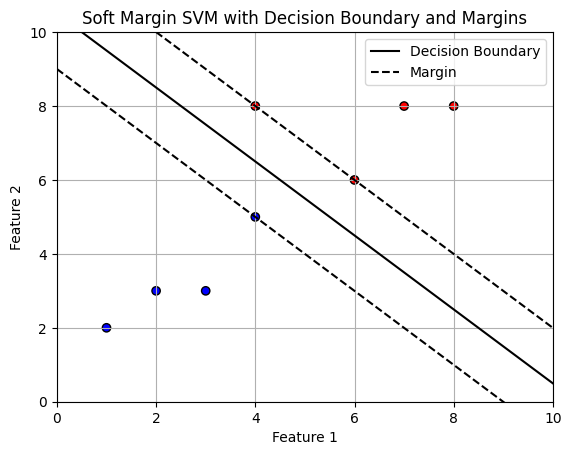

In [ ]:
# 결정 경계 시각화
w = model.coef_[0]
b = model.intercept_[0]
print(w) # 2/3, 2/3
print(b) # -7.0
x_plot = np.linspace(0, 10, 100)
y_plot = -(w[0] * x_plot + b) / w[1]

# 마진 경계 계산
margin = 1 / np.linalg.norm(w)
y_margin_positive = -(w[0] * x_plot + b - 1) / w[1]
y_margin_negative = -(w[0] * x_plot + b + 1) / w[1]

# 마진 시각화
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.plot(x_plot, y_plot, 'k-', label='Decision Boundary')
plt.plot(x_plot, y_margin_positive, 'k--', label='Margin')
plt.plot(x_plot, y_margin_negative, 'k--')

plt.xlim(0, 10)
plt.ylim(0, 10)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Soft Margin SVM with Decision Boundary and Margins')
plt.legend()
plt.grid(True)
plt.show()

### 1.3 프로젝트 (SVC)

In [27]:
from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix

#### **Linear SVC**

In [28]:
iris = load_iris()

X = iris.data[:, :2]
y = iris.target

C = 1
clf = SVC(kernel = "linear", C=C)
clf.fit(X,y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [29]:
y_pred = clf.predict(X) # 학습 데이터의 재예측 (실습용)
confusion_matrix(y, y_pred) # 따라서, 분류 결과가 상당히 정확할 수밖에 없음을 감안해야 함

array([[50,  0,  0],
       [ 0, 38, 12],
       [ 0, 15, 35]])

#### Q3.1 위 예시처럼, 옵션을 linear로 설정해도 되지만, sklearn의 LinearSVC 함수를 사용해도 구현할 수 있습니다. LinearSVC로 재구현해주세요.

In [31]:
from sklearn.svm import LinearSVC

clf_lsvc = LinearSVC(C=1, max_iter=1000, random_state = 10)
clf_lsvc.fit(X,y)

y_pred_lsvc = clf_lsvc.predict(X)
confusion_matrix(y, y_pred_lsvc)

array([[49,  1,  0],
       [ 2, 30, 18],
       [ 0,  9, 41]])

#### **Kernal SVC**

#### Q3.2 Kernel SCV - non-linear한 형태의 SVM을 하나 이상 구현해주세요. 동일하게, 학습데이터를 predict하여 confusion matrix를 구해주세요.

In [32]:
# 1) RBF 커널 SVM
clf_rbf = SVC(kernel="rbf", C=1, gamma="scale")   # gamma는 RBF에서 중요
clf_rbf.fit(X, y)
y_pred_rbf = clf_rbf.predict(X)

print("=== RBF Kernel SVM Confusion Matrix (Train Predict) ===")
print(confusion_matrix(y, y_pred_rbf))


# 2) Polynomial 커널 SVM
clf_poly = SVC(kernel="poly", C=1, degree=3, gamma="scale", coef0=1)
clf_poly.fit(X, y)
y_pred_poly = clf_poly.predict(X)

print("\n=== Polynomial Kernel SVM Confusion Matrix (Train Predict) ===")
print(confusion_matrix(y, y_pred_poly))

=== RBF Kernel SVM Confusion Matrix (Train Predict) ===
[[50  0  0]
 [ 0 38 12]
 [ 0 15 35]]

=== Polynomial Kernel SVM Confusion Matrix (Train Predict) ===
[[50  0  0]
 [ 0 38 12]
 [ 0 17 33]]


#### 시각화

#### Q3.3 아래 예시 plot처럼, linear model과 non-linear 모델의 시각화 결과를 출력해주세요.

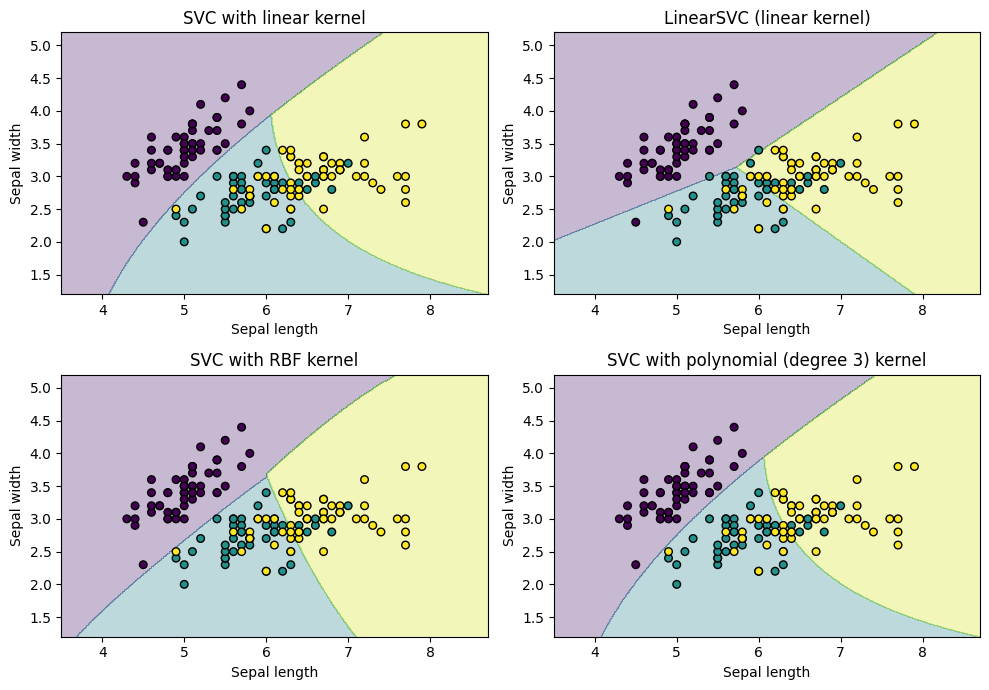

In [ ]:

# 결정 경계 그리는 함수 생성
def plot_decision_regions(ax, clf, X, y, title):
    # mesh grid 생성
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )
    
    # 격자 점들에 대해 예측
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # 배경(결정 영역)
    ax.contourf(xx, yy, Z, alpha=0.3)
    
    # 산점도(원본 데이터)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", s=30)
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Sepal length")
    ax.set_ylabel("Sepal width")


# 모델 정의
C = 1.0
models = [
    ("SVC with linear kernel", clf),
    ("LinearSVC (linear kernel)", clf_lsvc),
    ("SVC with RBF kernel", clf_rbf),
    ("SVC with polynomial (degree 3) kernel", clf_poly),
]

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.ravel()

for ax, (title, clf) in zip(axes, models):
    plot_decision_regions(ax, clf, X, y, title)

plt.tight_layout()
plt.show()